In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

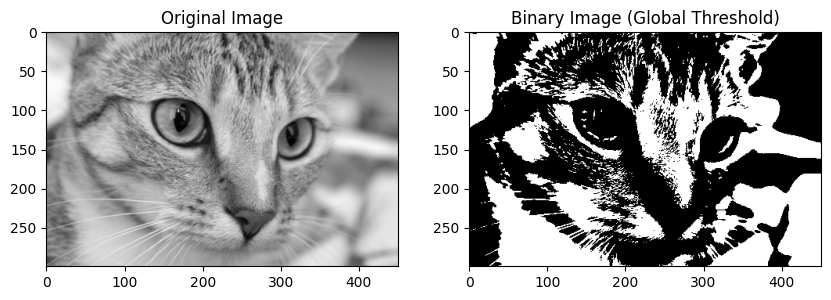

In [3]:
image = cv2.imread("../data/benchmarks/cat.png", cv2.IMREAD_GRAYSCALE)

T = 127
_, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1,2,2)
plt.title("Binary Image (Global Threshold)")
plt.imshow(binary, cmap='gray')
plt.show()

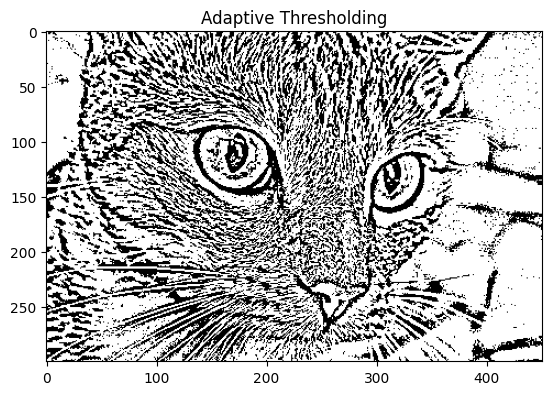

In [5]:
adaptive = cv2.adaptiveThreshold(
    image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,   # Block size
    2     # Constant subtracted from mean
)

plt.imshow(adaptive, cmap='gray')
plt.title("Adaptive Thresholding")
plt.show()

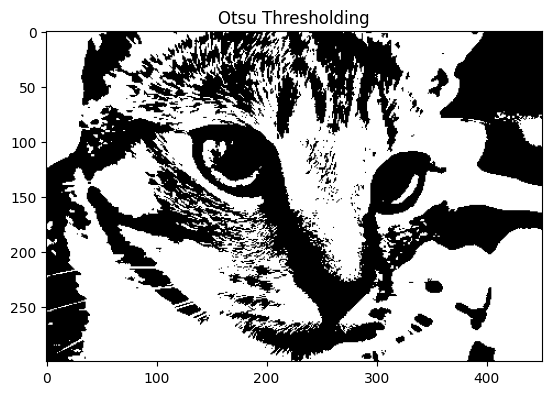

In [6]:
_, otsu = cv2.threshold(
    image,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(otsu, cmap='gray')
plt.title("Otsu Thresholding")
plt.show()

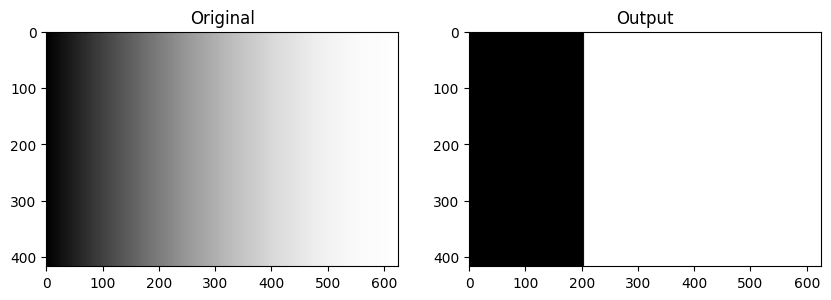

In [7]:
image = cv2.imread("../data/benchmarks/black-white.png")

new_image = np.copy(image)
new_image[new_image < 127] = 0
new_image[new_image >= 127] = 255

plt.figure(figsize=[10,5])
plt.subplot(121);plt.imshow(image, cmap='gray');plt.title("Original");
plt.subplot(122);plt.imshow(new_image, cmap='gray');plt.title("Output");

127.0


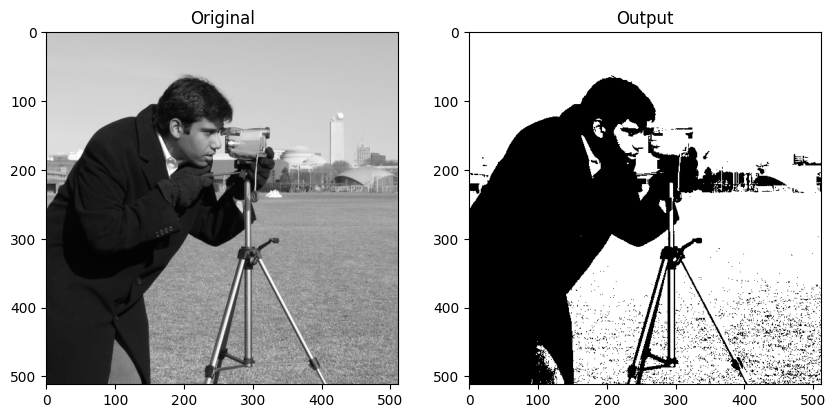

In [11]:
image = cv2.imread("../data/benchmarks/camera.png", cv2.IMREAD_GRAYSCALE)

retval, image_output = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

print(retval)
plt.figure(figsize=[10,5])
plt.subplot(121);plt.imshow(image, cmap='gray');plt.title("Original");
plt.subplot(122);plt.imshow(image_output, cmap='gray');plt.title("Output");

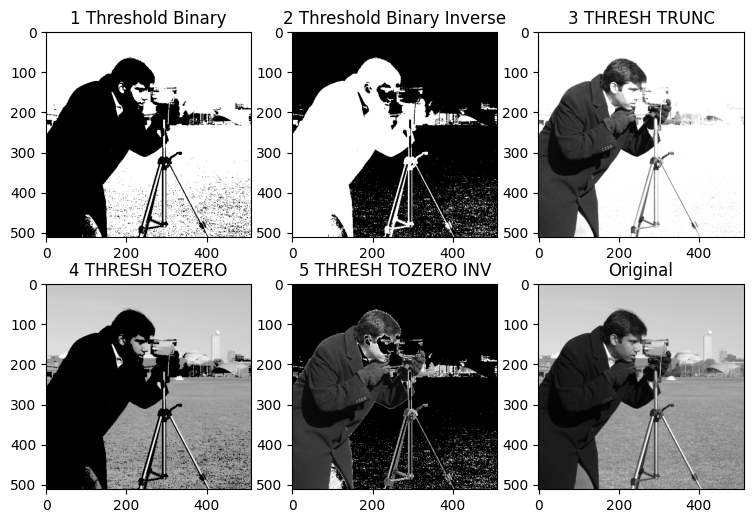

In [12]:
ret1,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Values below 127 go to 255 and values above 127 go to 0 (reverse of above)
ret2,thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)

# Values above 127 are truncated (held) at 127 (the 255 argument is unused)
ret3,thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)

# Values below 127 go to 0, above 127 are unchanged
ret4,thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)

# Resever of above, below 127 is unchanged, above 127 goes to 0
ret5,thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)

plt.figure(figsize=[9,6])
plt.subplot(231);plt.imshow(thresh1, cmap='gray');plt.title("1 Threshold Binary");
plt.subplot(232);plt.imshow(thresh2, cmap='gray');plt.title("2 Threshold Binary Inverse");
plt.subplot(233);plt.imshow(thresh3, cmap='gray');plt.title("3 THRESH TRUNC");
plt.subplot(234);plt.imshow(thresh4, cmap='gray');plt.title("4 THRESH TOZERO");
plt.subplot(235);plt.imshow(thresh5, cmap='gray');plt.title("5 THRESH TOZERO INV");
plt.subplot(236);plt.imshow(image, cmap='gray');plt.title("Original");

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

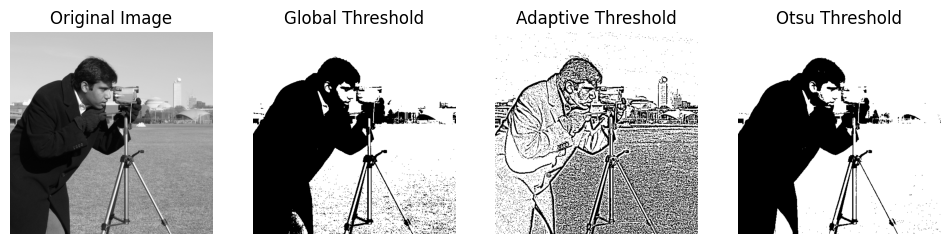

In [13]:
# Global Thresholding
_, binary_global = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Adaptive Thresholding
binary_adaptive = cv2.adaptiveThreshold(
    image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)

# Otsu's Thresholding
_, binary_otsu = cv2.threshold(
    image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Display results
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(binary_global, cmap='gray')
plt.title("Global Threshold")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(binary_adaptive, cmap='gray')
plt.title("Adaptive Threshold")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(binary_otsu, cmap='gray')
plt.title("Otsu Threshold")
plt.axis('off')

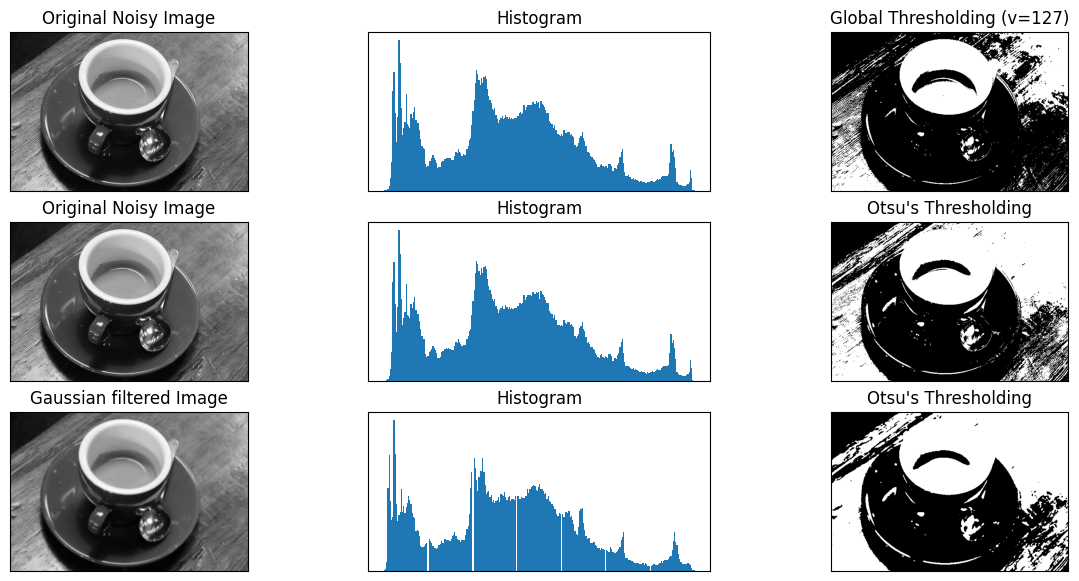

In [16]:
img = cv2.imread('../data/benchmarks/coffee.png',0)
# global thresholding
ret1,th1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
# Otsu's thresholding
ret2,th2 = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
# Otsu's thresholding after Gaussian filtering
blur = cv2.GaussianBlur(img,(5,5),0)
ret3,th3 = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]

plt.figure(figsize=[15,7])
for i in range(3):
    #first column
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray'),
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    #second column
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    #third column
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()